In [8]:
import os 
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

from sklearn.linear_model import LinearRegression, Ridge 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import shap 

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi":150,
    "font.family":"sans-serif",
    "axes.spines.top":False,
    "axes.spines.right":False
})

os.makedirs("../figures", exist_ok=True)
os.makedirs("../models", exist_ok=True)

df = pd.read_csv("../data/processed/solid_electrolyte_features.csv")
print(f"Dataset Loaded: {df.shape[0]} samples, {df.shape[1]} features")
print(df.dtypes)

Dataset Loaded: 15362 samples, 22 features
material_id                      str
formula                          str
band_gap                     float64
energy_above_hull            float64
formation_energy_per_atom    float64
volume                       float64
density                      float64
nsites                         int64
nelements                      int64
spacegroup                       str
crystal_system                   str
li_fraction                  float64
na_fraction                  float64
mean_atomic_number           float64
mean_electronegativity       float64
std_electronegativity        float64
mean_atomic_radius           float64
std_atomic_radius            float64
mean_ionic_radius            float64
std_ionic_radius             float64
ion_type                         str
electrolyte_family               str
dtype: object


In [3]:
FEATURES = [ 
    "formation_energy_per_atom",  
    "energy_above_hull",
    "volume",
    "density",
    "nsites",
    "nelements",
    "li_fraction",
    "na_fraction",
    "mean_atomic_number",
    "mean_electronegativity",
    "std_electronegativity",
    "mean_atomic_radius",
    "std_atomic_radius",
    "mean_ionic_radius",
]

TARGET = "band_gap"

df_model = df[FEATURES + [TARGET]].dropna()
print(f"Model Dataset: {df_model.shape[0]} samples, {df_model.shape[1]} features")

X = df_model[FEATURES].values
y = df_model[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)
print(f"Training Set: {X_train.shape[0]} samples")
print(f"Validation Set: {X_val.shape[0]} samples")
print(f"Test Set: {X_test.shape[0]} samples")

Model Dataset: 15362 samples, 15 features
Training Set: 11098 samples
Validation Set: 1959 samples
Test Set: 2305 samples


In [4]:
models = {
    "Linear Regression":Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge Regression":Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            n_estimators=200, 
            max_depth=10, 
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingRegressor(
            n_estimators=200, 
            learning_rate=0.05, 
            max_depth=5, 
            random_state=42
        ))
    ])
}

In [5]:
def evaluate(model,X_tr,y_tr,X_te,y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        "R2": r2_score(y_te, y_pred),
        "MAE": mean_absolute_error(y_te, y_pred),
        "RMSE": mean_squared_error(y_te, y_pred)**0.5,
        "y_pred": y_pred
    }
results = {}
for name, model in models.items():
    res = evaluate(model, X_train, y_train, X_test, y_test)
    results[name] = res
    print(f"{name} - R2: {res['R2']:.3f}, MAE: {res['MAE']:.3f}, RMSE: {res['RMSE']:.3f}")

Linear Regression - R2: 0.306, MAE: 0.839, RMSE: 1.046
Ridge Regression - R2: 0.306, MAE: 0.839, RMSE: 1.046
Random Forest - R2: 0.599, MAE: 0.610, RMSE: 0.796
Gradient Boosting - R2: 0.616, MAE: 0.597, RMSE: 0.779


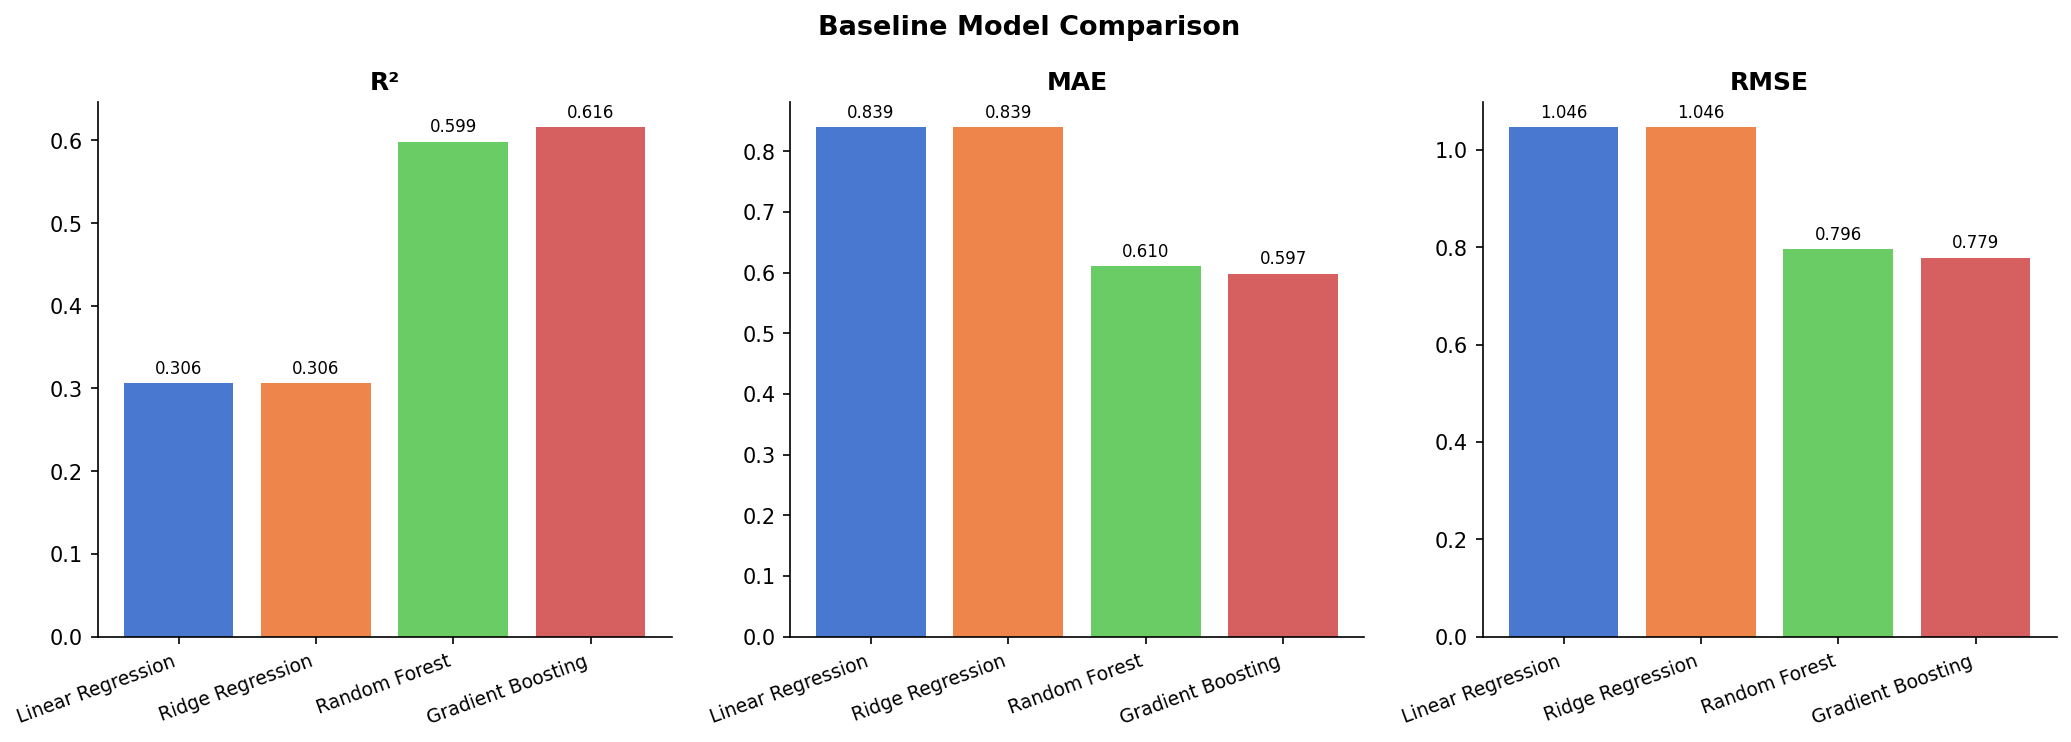

Saved fig08_model_comparison.png


In [11]:
metrics_df = pd.DataFrame({
    name: {"R²": res["R2"], "MAE": res["MAE"], "RMSE": res["RMSE"]}
    for name, res in results.items()
}).T

fig, axes = plt.subplots(1, 3, figsize=(14, 5))  # 1 row, 3 cols
metrics = ["R²", "MAE", "RMSE"]
colors = sns.color_palette("muted", len(models))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(metrics_df.index, metrics_df[metric], color=colors)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_xticklabels(metrics_df.index, rotation=20, ha="right", fontsize=9)
    ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=3)

fig.suptitle("Baseline Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/fig08_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig08_model_comparison.png")

Best model: Gradient Boosting (R² = 0.616)


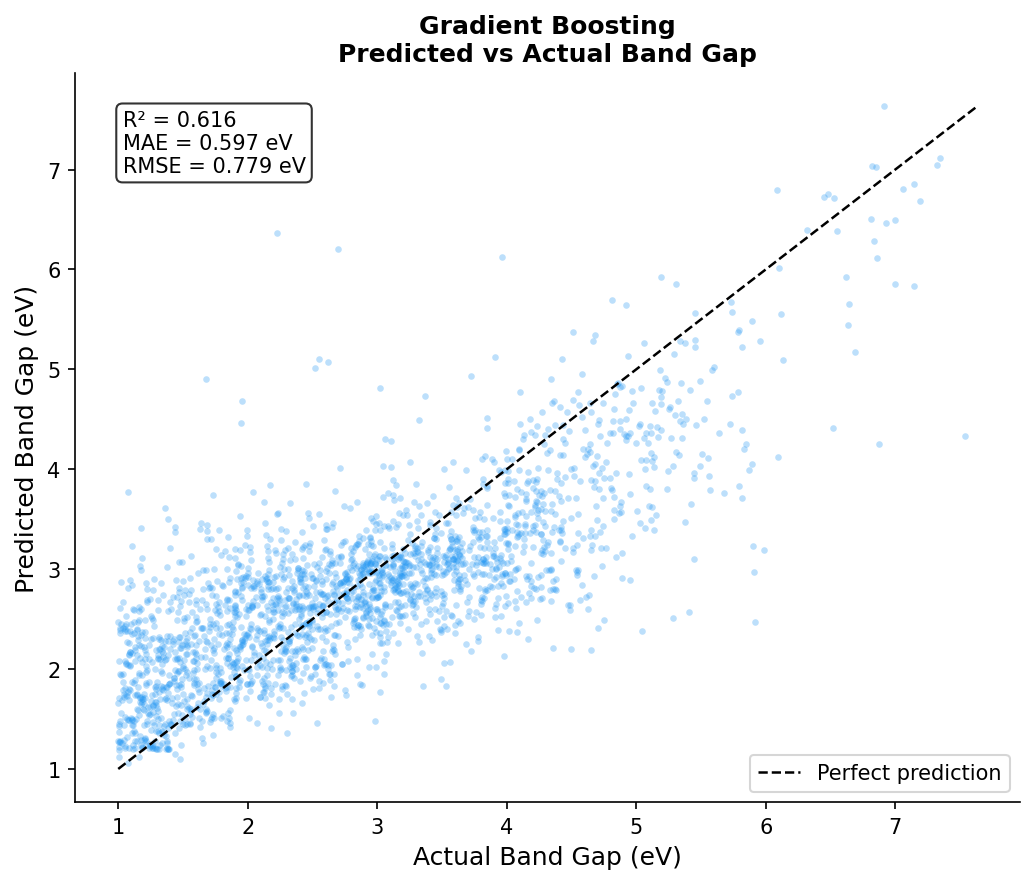

Saved fig09_predicted_vs_actual.png


In [18]:
# Identify best model by R²
best_name = max(results, key=lambda k: results[k]["R2"])
best_pred = results[best_name]["y_pred"]
print(f"Best model: {best_name} (R² = {results[best_name]['R2']:.3f})")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test,best_pred,alpha=0.3,s=10,color="#2196F3",linewidth=0)

lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
ax.plot(lims,lims,"k--",linewidth=1.2,label="Perfect prediction")

ax.set_xlabel("Actual Band Gap (eV)", fontsize=12)
ax.set_ylabel("Predicted Band Gap (eV)", fontsize=12)
ax.set_title(f"{best_name}\nPredicted vs Actual Band Gap", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)

r2 = results[best_name]["R2"]
mae = results[best_name]["MAE"]
rmse = results[best_name]["RMSE"]
ax.text(0.05, 0.95, f"R² = {r2:.3f}\nMAE = {mae:.3f} eV\nRMSE = {rmse:.3f} eV", transform=ax.transAxes,
        fontsize=10, verticalalignment="top", bbox=dict(boxstyle="round",facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("../figures/fig09_predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig09_predicted_vs_actual.png")

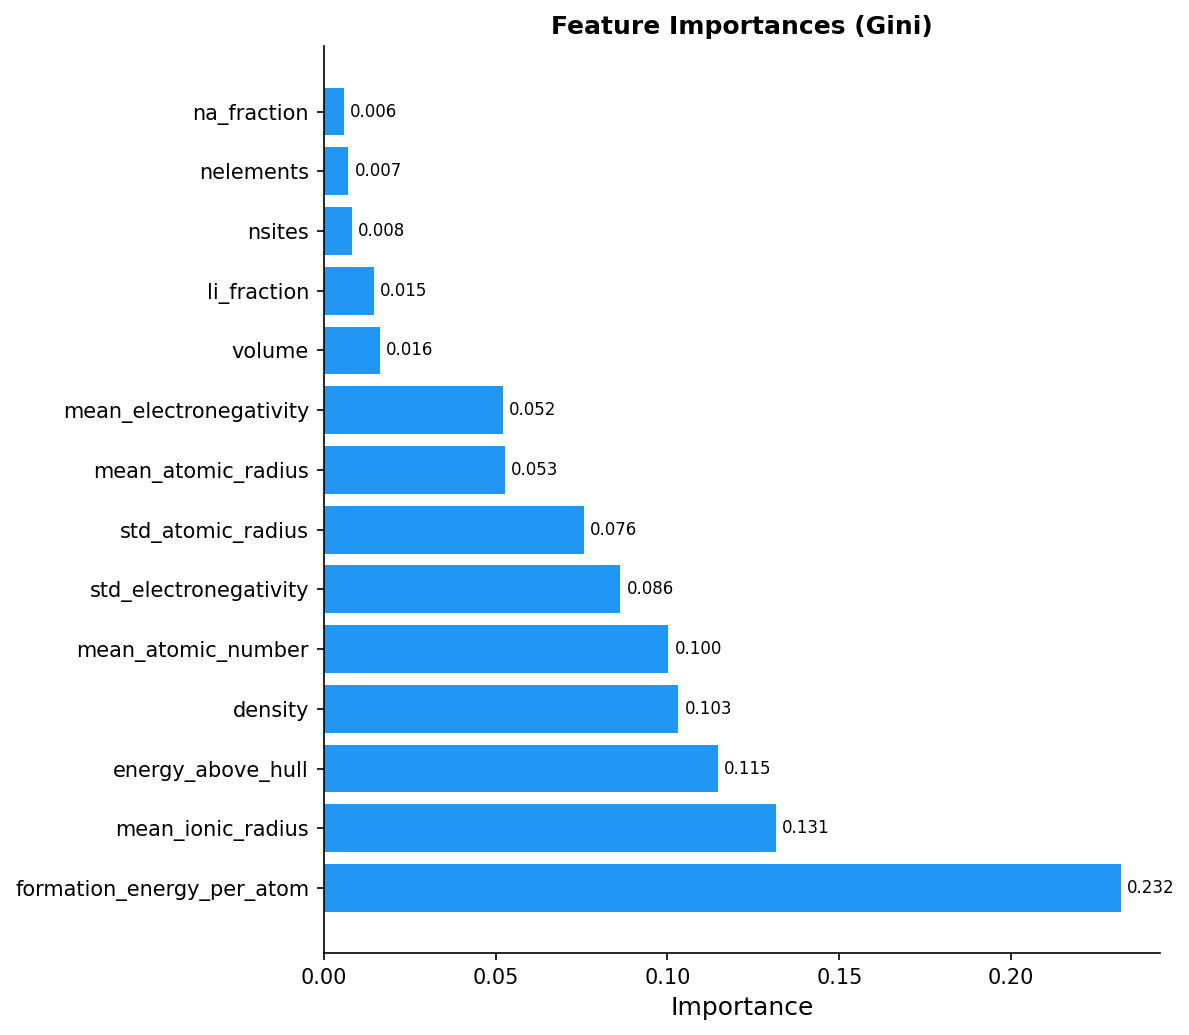

Saved fig10_rf_feature_importance.png


In [19]:
rf_model = models["Random Forest"].fit(X_train, y_train)
importances = rf_model.named_steps["model"].feature_importances_
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
bars = ax.barh(importance_df["Feature"], importance_df["Importance"], 
               color="#2196F3", edgecolor="none")
ax.set_title("Feature Importances (Gini)", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance", fontsize=12)
ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=3)

plt.tight_layout()
plt.savefig("../figures/fig10_rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig10_rf_feature_importance.png")

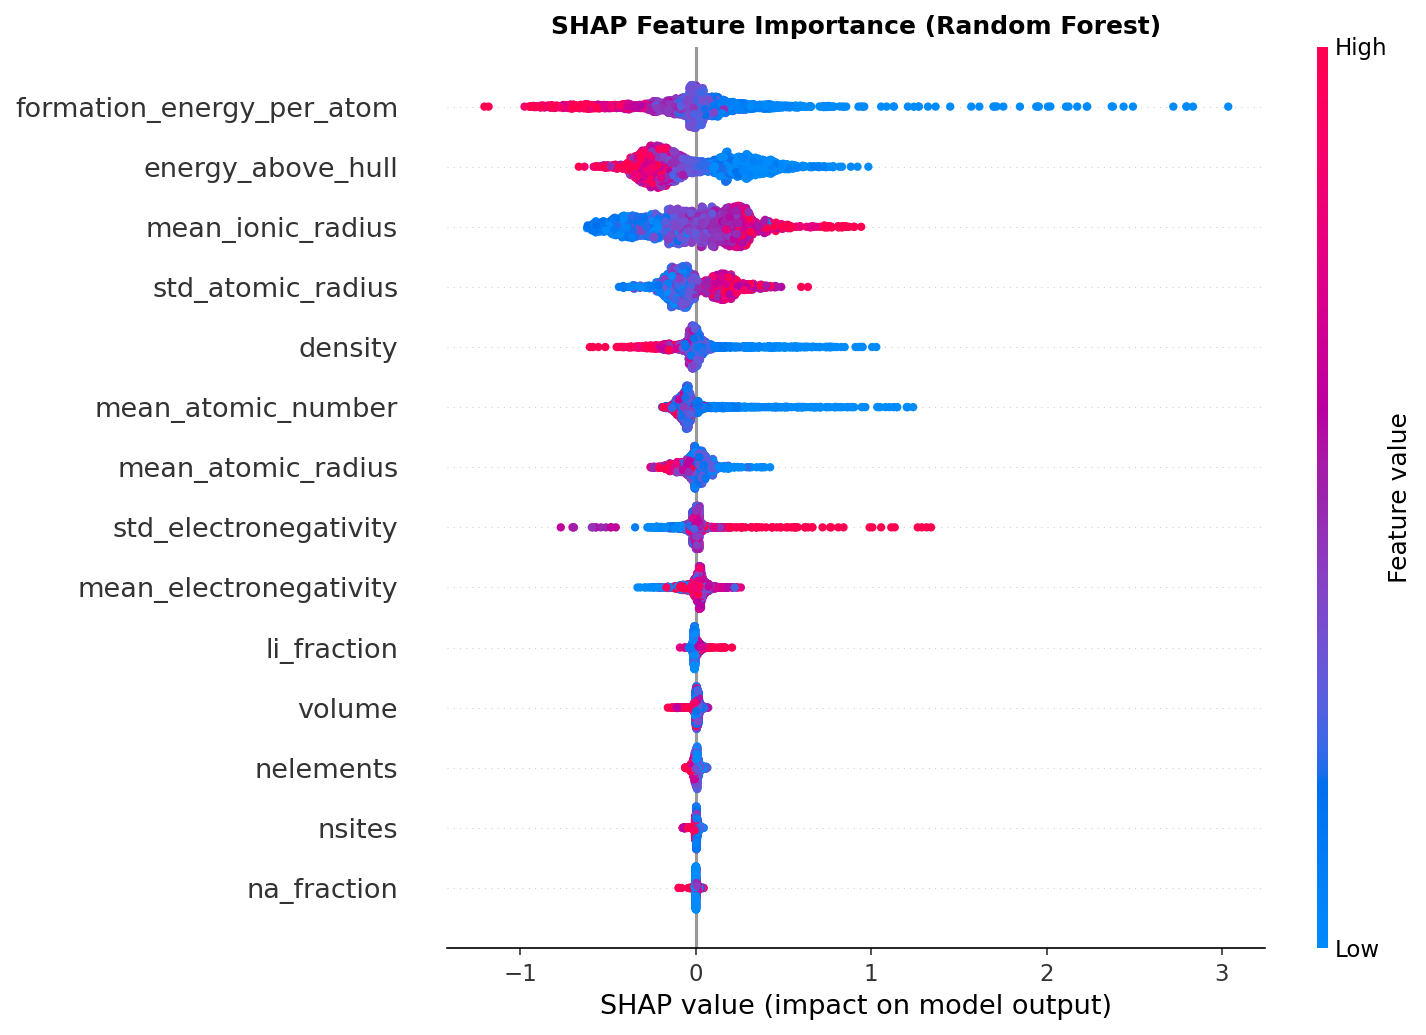

Saved fig11_shap_summary.png


In [21]:
rf_raw = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
) 

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_raw.fit(X_train_scaled, y_train)

explainer = shap.TreeExplainer(rf_raw)
shap_values = explainer.shap_values(X_test_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test_scaled,
    feature_names=FEATURES,
    show=False,plot_size=None
)
plt.title("SHAP Feature Importance (Random Forest)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/fig11_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig11_shap_summary.png")   

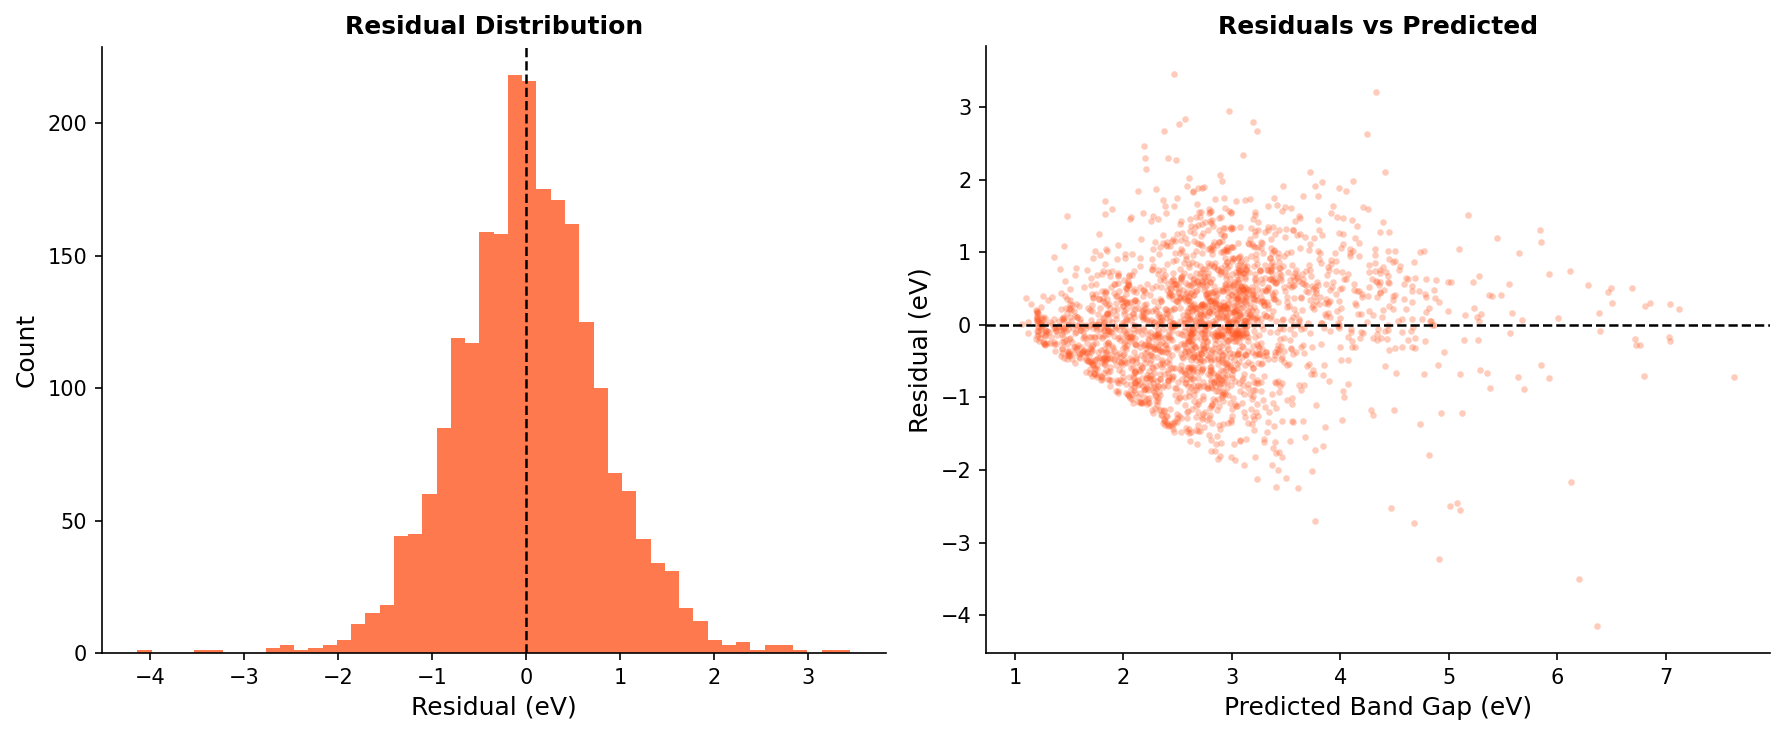

Saved fig12_residuals.png


In [25]:
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(residuals, bins=50, color="#FF5722", edgecolor="none", alpha=0.8)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_xlabel("Residual (eV)", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].set_title("Residual Distribution", fontsize=12, fontweight="bold")

axes[1].scatter(best_pred, residuals, alpha=0.3, s=10,
                color="#FF5722", linewidths=0)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Predicted Band Gap (eV)", fontsize=12)
axes[1].set_ylabel("Residual (eV)", fontsize=12)
axes[1].set_title("Residuals vs Predicted", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../figures/fig12_residuals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved fig12_residuals.png")

In [26]:
summary = pd.DataFrame({
    name: {"R²": res["R2"], "MAE": res["MAE"], "RMSE": res["RMSE"]}
    for name, res in results.items()
}).T
summary.to_csv("../data/processed/baseline_model_summary.csv")
print("Saved baseline_model_summary.csv")
print(summary)
print(f"\nBest model: {best_name}")
print(f"R²: {results[best_name]['R2']:.3f}")
print(f"MAE: {results[best_name]['MAE']:.3f} eV")
print(f"RMSE: {results[best_name]['RMSE']:.3f} eV")
print("\nPhase 3 complete. GNN should exceed these baselines.")

Saved baseline_model_summary.csv
                         R²       MAE      RMSE
Linear Regression  0.306015  0.839117  1.046289
Ridge Regression   0.306012  0.839137  1.046291
Random Forest      0.598593  0.610131  0.795736
Gradient Boosting  0.615589  0.597381  0.778708

Best model: Gradient Boosting
R²: 0.616
MAE: 0.597 eV
RMSE: 0.779 eV

Phase 3 complete. GNN should exceed these baselines.
